# Figure 1.2

imports done


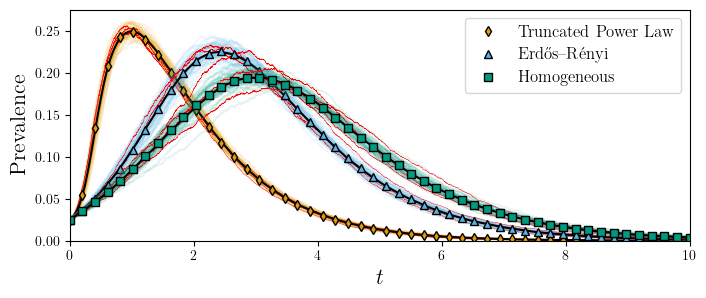

In [3]:
import EoN
import networkx as nx
from matplotlib import rc
import matplotlib.pylab as plt


import numpy as np

#handling random seeds as described in
#https://networkx.org/documentation/stable/reference/randomness.html
import random
random.seed(5)        # or any integer
np.random.seed(10)
rng = np.random.default_rng(4)

print('imports done')

colors = ['#5AB3E6','#FF2000','#009A80','#E69A00', '#CD9AB3', '#0073B3',
        '#F0E442']

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)



rho = 0.025
target_k = 6
#Ns=[10000]#, 1000000]
N=10000
tau = 0.5
gamma = 1.
ts = np.arange(0,40,0.05)
count = 50 #number of simulations to run for each



def generate_network(Pk, N, ntries = 100):
    r'''Generates an N-node random network whose degree distribution is given by Pk'''
    counter = 0
    while counter< ntries:
        counter += 1
        ks = []
        for ctr in range(N):
            ks.append(Pk())
        if sum(ks)%2 == 0:
            break
    if sum(ks)%2 ==1:
        raise EoN.EoNError("cannot generate even degree sum")
    G = nx.configuration_model(ks)  #output consistent due to random.seed() assigned above
    return G
 


#An erdos-renyi network has a Poisson degree distribution.
def PkPoisson():
    return rng.poisson(target_k)
def PsiPoisson(x):
    return np.exp(-target_k*(1-x))
def DPsiPoisson(x):
    return target_k*np.exp(-target_k*(1-x))
    
    
    
#a regular (homogeneous) network has a simple generating function.

def PkHomogeneous():
    return target_k
def PsiHomogeneous(x):
    return x**target_k
def DPsiHomogeneous(x):
    return target_k*x**(target_k-1)




#The following 30 - 40 lines or so are devoted to defining the degree distribution
#and the generating function of the truncated power law network.

#defining the power law degree distribution here:
assert(target_k==6) #if you've changed target_k, then you'll
                   #want to update the range 1..61 and/or 
                   #the exponent 1.5.

PlPk = {}
exponent = 1.5
kave = 0
for k in range(1,61):
    PlPk[k]=k**(-exponent)
    kave += k*PlPk[k]
   
normfactor= sum(PlPk.values())
for k in PlPk:
    PlPk[k] /= normfactor

def PkPowLaw(): 
    r = rng.random()
    for k in PlPk:
        r -= PlPk[k]
        if r<0:
            return k

def PsiPowLaw(x):
    #print PlPk
    rval = 0
    for k in PlPk:
        rval += PlPk[k]*x**k
    return rval

def DPsiPowLaw(x):
    rval = 0
    for k in PlPk:
        rval += k*PlPk[k]*x**(k-1)
    return rval
#End of power law network properties.   
 
 
 
 

def process_degree_distribution(N, Pk, color, Psi, DPsi, symbol, markersize, label, count, rng):
    #scaled_tf = 10**(1/1.5)
    #scaled_rep_times = np.linspace(0, scaled_tf, 10)
#    report_times = scaled_rep_times**1.5
#    print(report_times)
    report_times = np.linspace(0,10,200)
    sums = 0*report_times
    for counter in range(count-3):
        G = generate_network(Pk, N)
        #print(G.order())
        #print(G.size())
        #print(list(G.neighbors(2)))
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, rng=rng)
        #print(t[0])
        plt.plot(t, I*1./N, '-', color = color, 
                                alpha = 0.1, linewidth=1)
        subsampled_I = EoN.subsample(report_times, t, I)
        sums += subsampled_I*1./N
    
    #plt.plot(report_times, ave, color = 'k')
    
    for counter in range(3):  #do 3 highlighted simulations
        G = generate_network(Pk, N)
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, rng=rng)
        plt.plot(t, I*1./N, '-', color = 'r', linewidth=0.3)
        subsampled_I = EoN.subsample(report_times, t, I)
        sums += subsampled_I*1./N
    ave = sums/count
    #print(report_times)
    plt.plot(report_times, ave, color = 'k')
    #Do EBCM    
    N= G.order()#N is arbitrary, but included because our implementation of EBCM assumes N is given.
    t, S, I, R = EoN.EBCM_uniform_introduction(N, Psi, DPsi, tau, gamma, rho, tmin=0, tmax=10, tcount = 50)
    plt.plot(t, I/N, symbol, color = color, markeredgecolor='k', markersize = markersize, label=label)




plt.figure(figsize=(8,3))
    
    


#Powerlaw
process_degree_distribution(N, PkPowLaw, colors[3], PsiPowLaw, DPsiPowLaw, 'd', 5, r'Truncated Power Law', count, rng)

#Poisson
process_degree_distribution(N, PkPoisson, colors[0], PsiPoisson, DPsiPoisson, '^', 6, r'Erd\H{o}s--R\'{e}nyi', count, rng)

#Homogeneous
process_degree_distribution(N, PkHomogeneous, colors[2], PsiHomogeneous, DPsiHomogeneous, 's', 5.5, r'Homogeneous', count, rng)

plt.xlabel(r'$t$', fontsize=16)
plt.ylabel(r'Prevalence', fontsize=16)
plt.legend(loc = 'upper right', numpoints = 1, fontsize=12)

plt.axis(xmax=10, xmin=0, ymin=0)
plt.savefig('fig1p2.png', bbox_inches='tight', dpi=900)
#np.random.seed(11)


Now Figure 1.5

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
epi_count = 32975


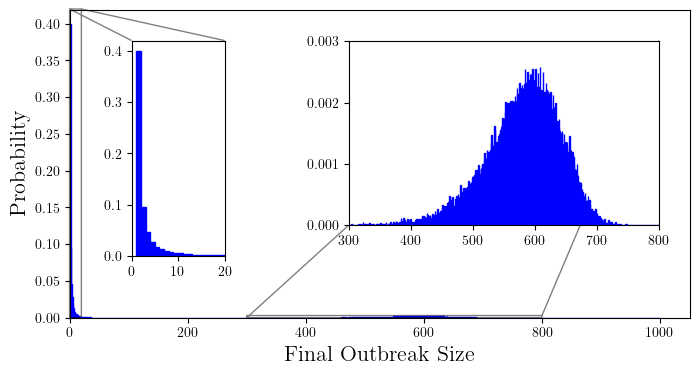

In [1]:
import EoN
import networkx as nx
from matplotlib import rc
import matplotlib.pyplot as plt
import numpy as np


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


#commands to make sure nx has consistent random numbers
import random
random.seed(5)        # or any integer
np.random.seed(10)
rng = np.random.default_rng(123)


N=1000
gamma = 1
tau = 1.5/N
G = nx.complete_graph(N)
iterations = 100000

epi_count = 0
D = []
for counter in range(iterations):
    if counter%1000 == 0: 
        print(counter)
    t, S, I, R = EoN.fast_SIR(G, tau, gamma, rng=rng)
    D.append(R[-1])
    if R[-1]>100:
        epi_count += 1

print("epi_count = {}".format(epi_count))

fig, ax = plt.subplots(figsize=(8,4))

ax.hist(D, bins = np.arange(0,N+1), density=True, color='blue', edgecolor='blue')

inset1 = ax.inset_axes([0.45,0.3,0.5,0.6],
                 xlim=(300, 800), ylim=(0, 0.00301))
inset1.hist(D, bins = np.arange(1,N+1), density=True, color='blue', edgecolor='blue')


inset2 = ax.inset_axes([0.1,0.2,0.15,0.7],
                 xlim=(0, 20), ylim=(0, 0.42))
inset2.hist(D, bins = np.arange(1,N+1), density=True, color='blue', edgecolor='blue')


ax.indicate_inset_zoom(inset1, edgecolor="black")
ax.indicate_inset_zoom(inset2, edgecolor="black")
ax.set_xlabel('Final Outbreak Size', fontsize=16)
ax.set_ylabel('Probability', fontsize=16)
plt.ylim(ymin=0)
plt.xlim(xmin=0)
plt.savefig('fig1p5.png', bbox_inches='tight', dpi=900)